In [1]:
import os

try:
    from occultence import *
except:
    os.chdir("../..")
    from occultence import *
    
import occultence
occultence.version()

'0.5.7'

(0.99, 1.015)

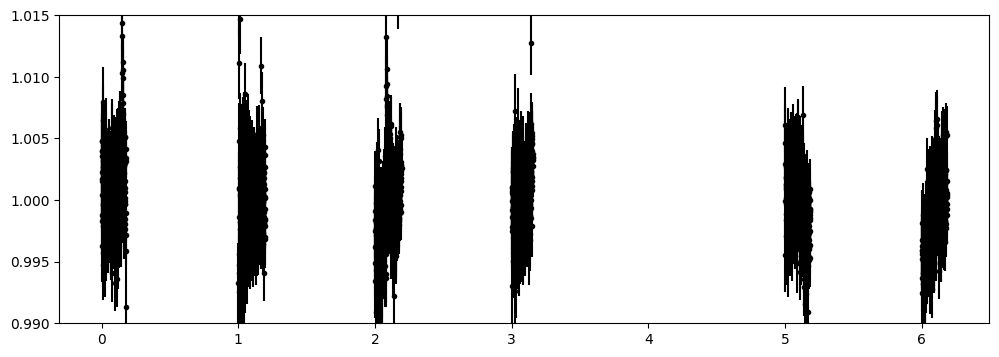

In [2]:
pre_bin = False
file_name = "../../Data/0000000000000000001.csv"
gaia_id = file_name.split("/")[-1].replace(".csv","")

data = pd.read_csv(file_name)

t = data["bjd"].values - data["bjd"].values[0]
f = data["diff_flux_use"].values
ferr = data["diff_error"].values

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
targ = LightCurve(name = "secondLC",
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':0.1*u.R_sun, 'M_star':0.1*u.M_sun})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



In [4]:
targ_with_transit = targ.inject_transit(per=2.55*u.d, 
                                        epoch=0.025 * u.d, 
                                        inc=90 * u.degree, 
                                        rp=1 * u.R_earth, 
                                        ld=[0.3,0.3])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='transit_model'>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: xlabel='Time [d]'>], dtype=object)

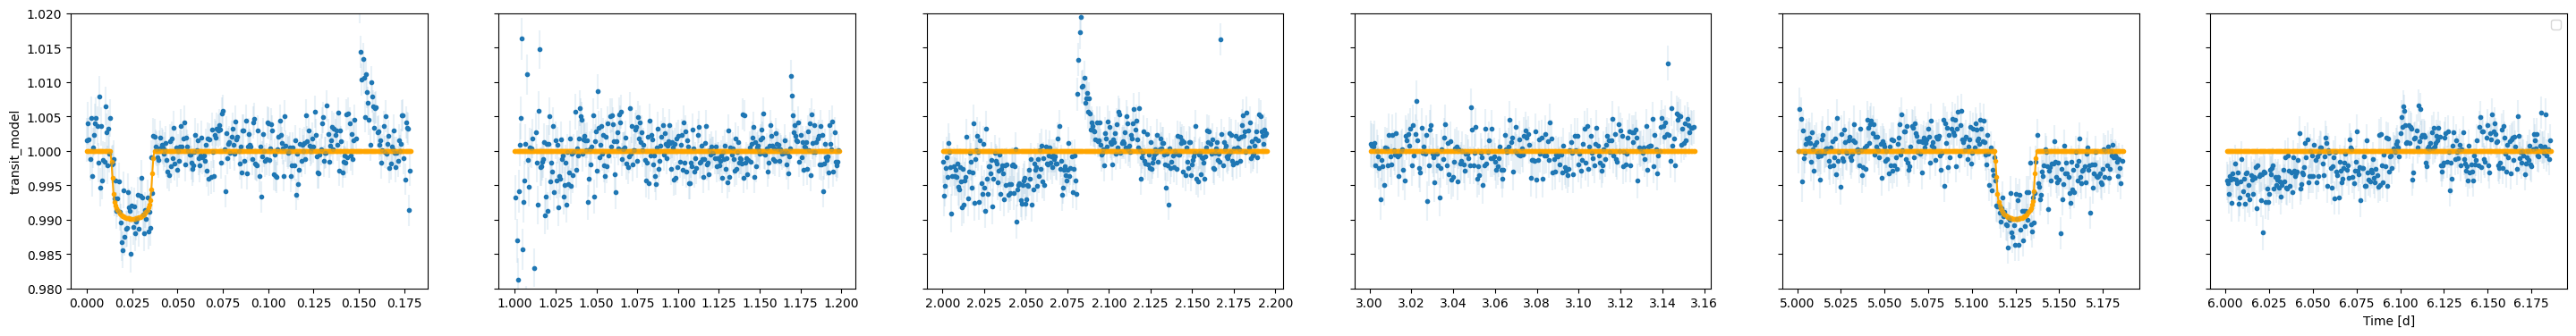

In [7]:
ax=targ_with_transit.plot()
targ_with_transit.plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")

In [5]:
per=2.55*u.d
epoch=0.025 * u.d
inc=90 * u.degree
rp=1 * u.R_earth
ld=[0.3,0.3]

planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
                                                          minimum_planet_radius=rp, 
                                                          maximum_planet_radius=rp,
                                                          minimum_period=per, 
                                                          maximum_period=per,
                                                        )
planets

,logP,phase,cosi,r_p,depth,duration,epoch,a,a_Rs,injected,...,rec_depth,rec_duration,rec_epoch,run,snr,target,r_s,m_s,teff,spt
0,0.40654,0.797768,0.000455,1.0,0.008405017877225193,0.024305,2.034308,3.6458425652160784 solRad,36.458425652160784,0.0,...,0.0,0.0,0.0,0.0,0.0,secondLC_inject,0.1 solRad,0.1 solMass,None,None


1/1...


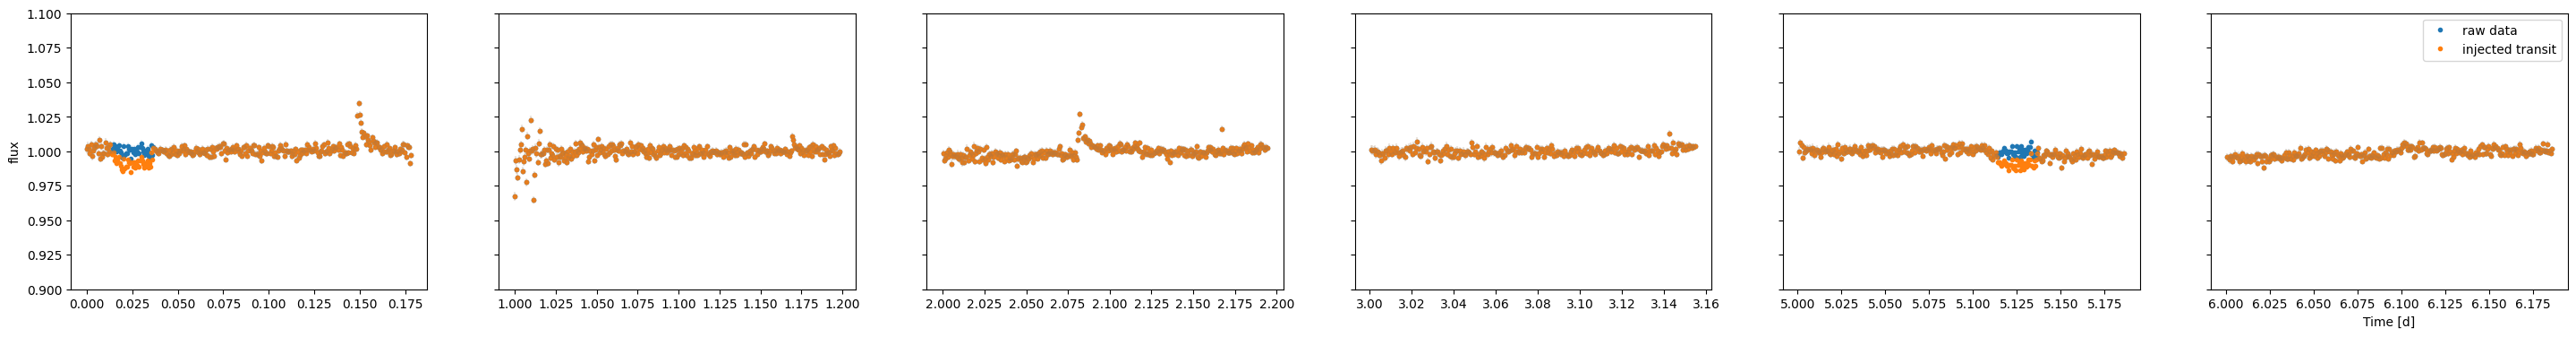

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...



            0.05230125523012552% of data is flagged as cosmics ⚡.
            
Time to clean LC: 0.6195409297943115


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 2 flare candidates with >30.0 s over 3$\sigma$
            


Time to remove flares: 0.6719348430633545


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


Running BLS Search
Number of Periods Checked:  47143
Period:  0.6365635172023879
Duration:  0.02
Depth:  0.008453271501519007
Power:  8.183614912722181


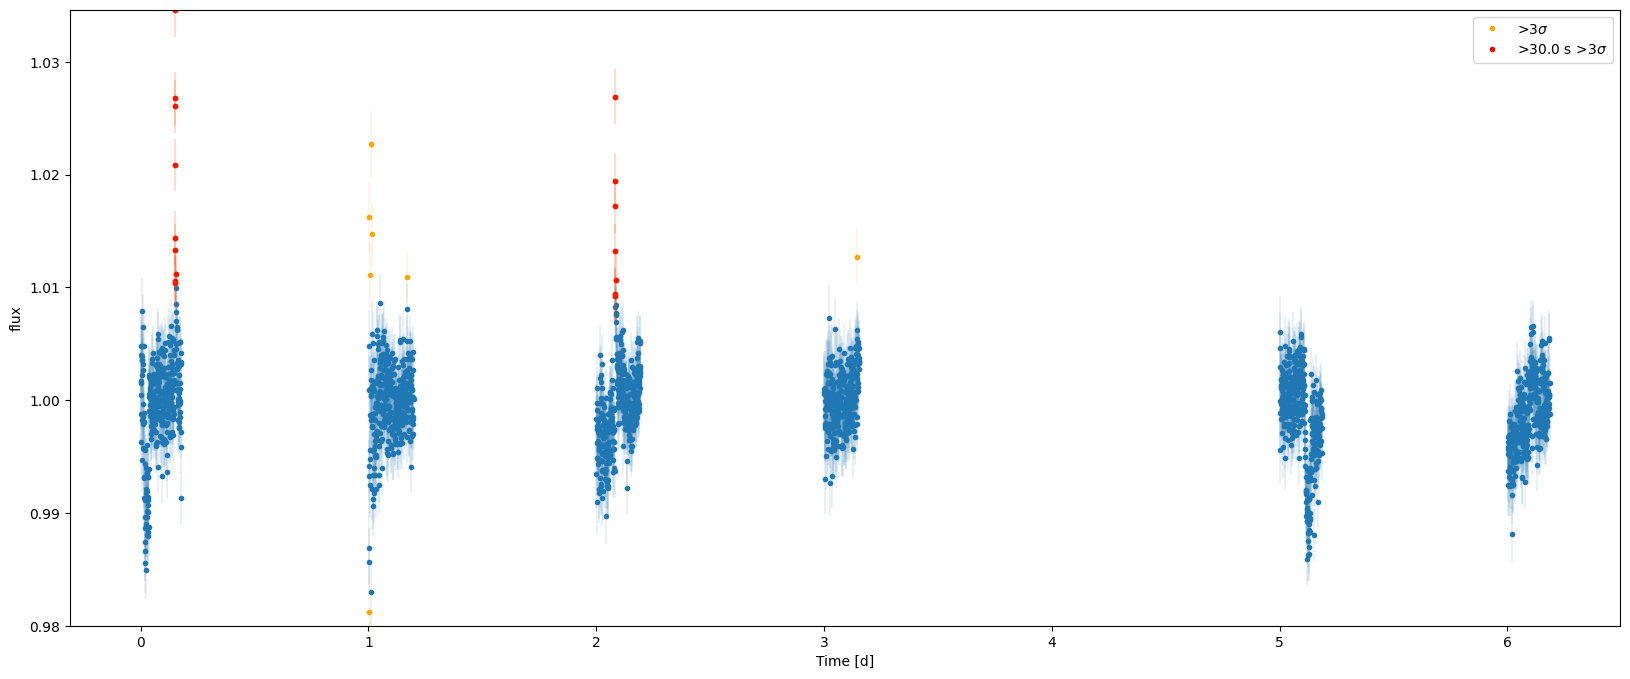

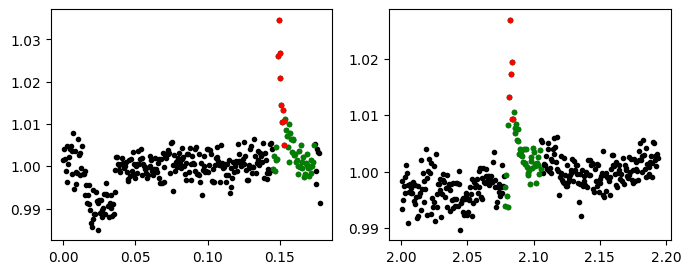

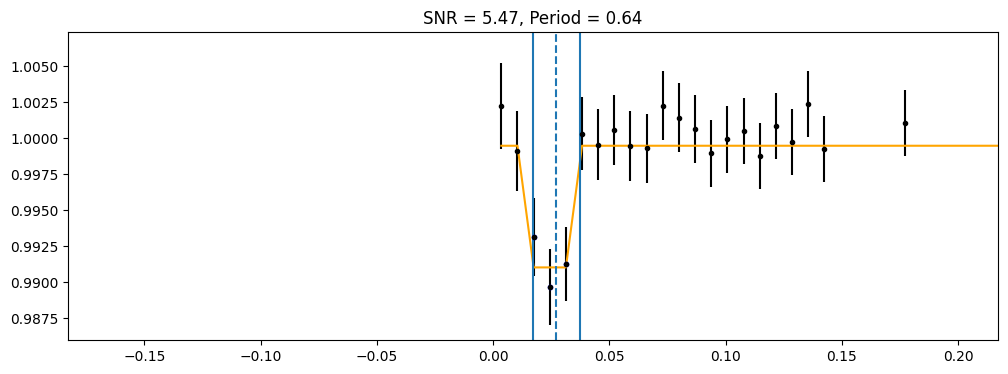

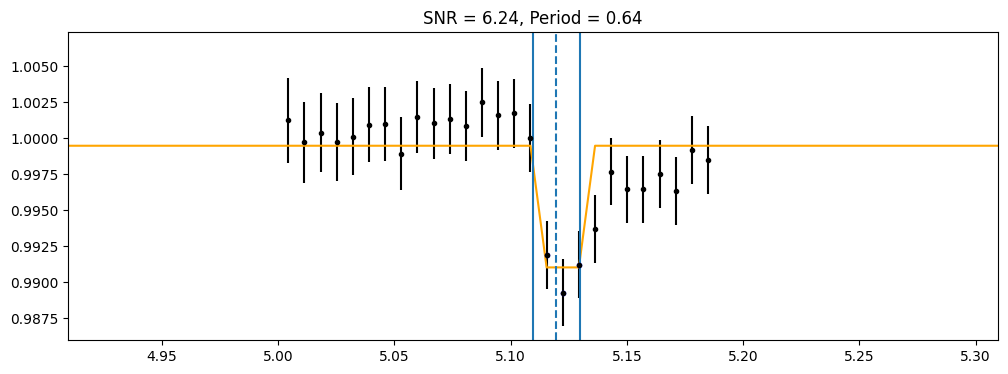

Time to BLS before detrending: 1.1442089080810547
Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-6.0299933  -6.31289892 -2.30258509]
Initial Params: AMP =  0.0018127705333067586 , SQEXP=  0.10000000000000002 , JITTER =  0.0024055100891274
Initial ln-likelihood: 291.63
Fitted GP HPs: [-26.92322547 -12.89560881  -3.87120101]
Fitted Params: AMP =  2.5090438477813815e-06 , SQEXP=  0.02083333333333333 , JITTER =  2.029512555294125e-12
Final ln-likelihood: 696.88


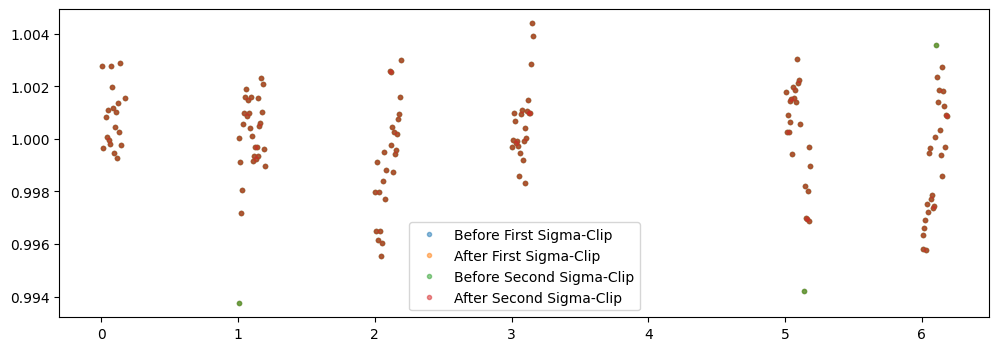

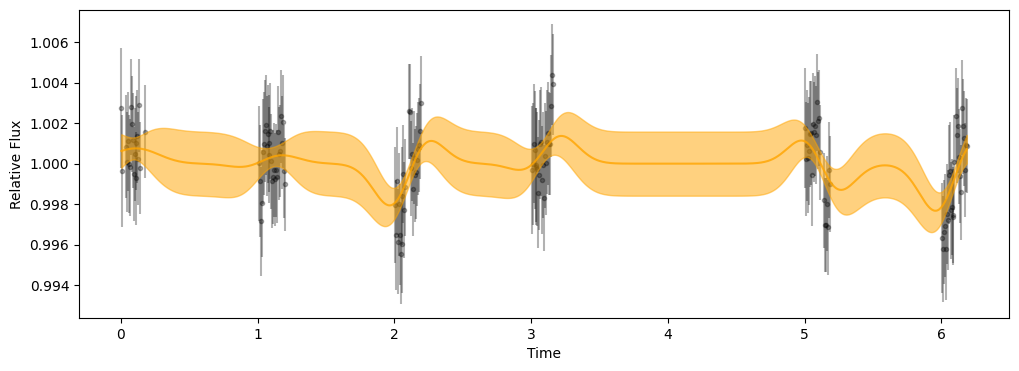

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to detrend: 1.9731693267822266


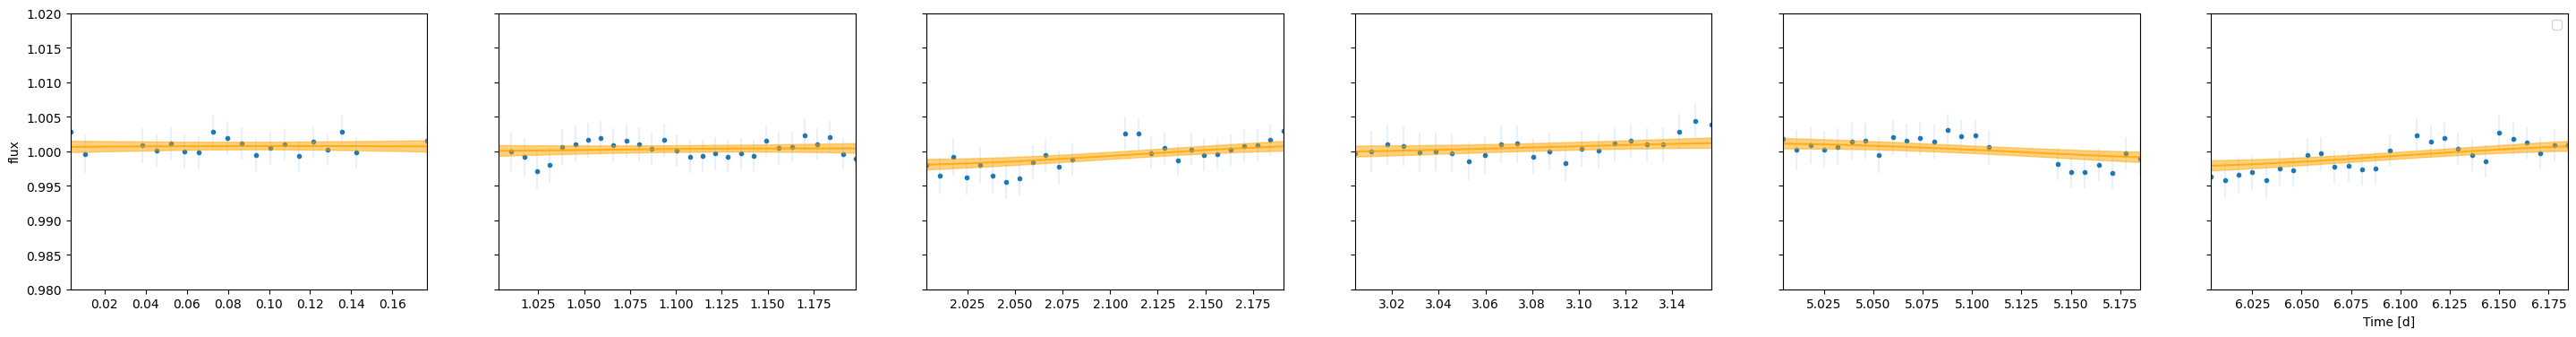

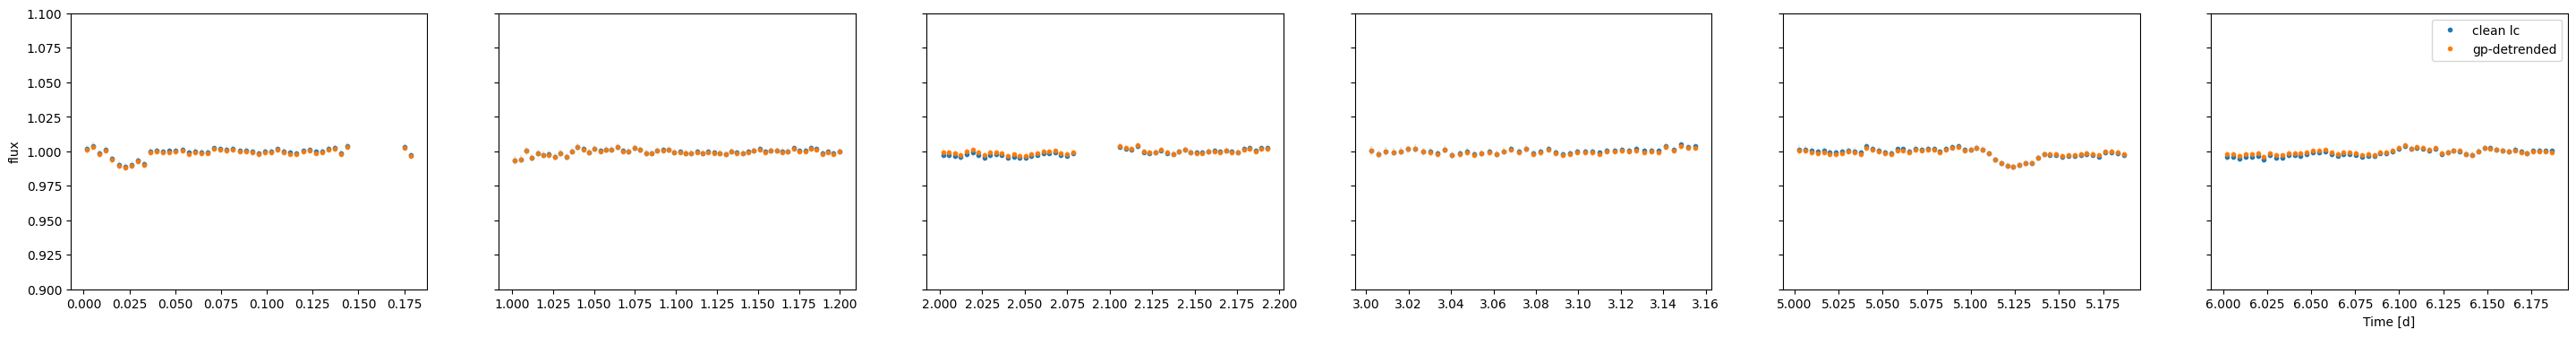

Running BLS Search
Number of Periods Checked:  47196
Period:  0.6377387224946418
Duration:  0.02
Depth:  0.009007126152835648
Power:  12.338280161785178


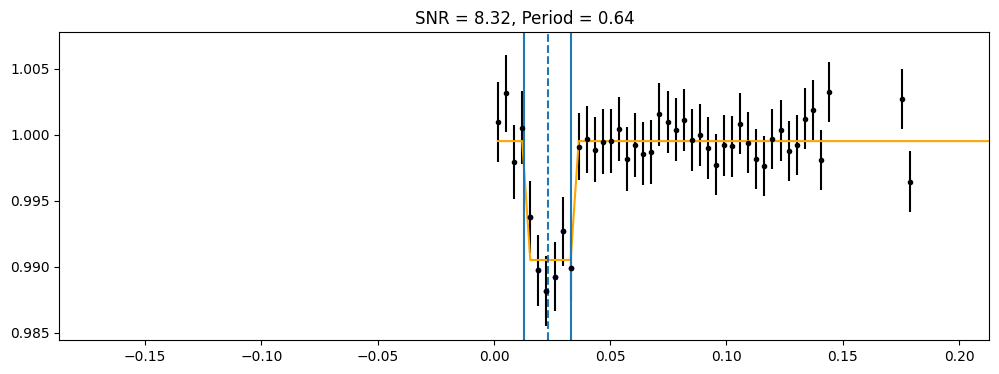

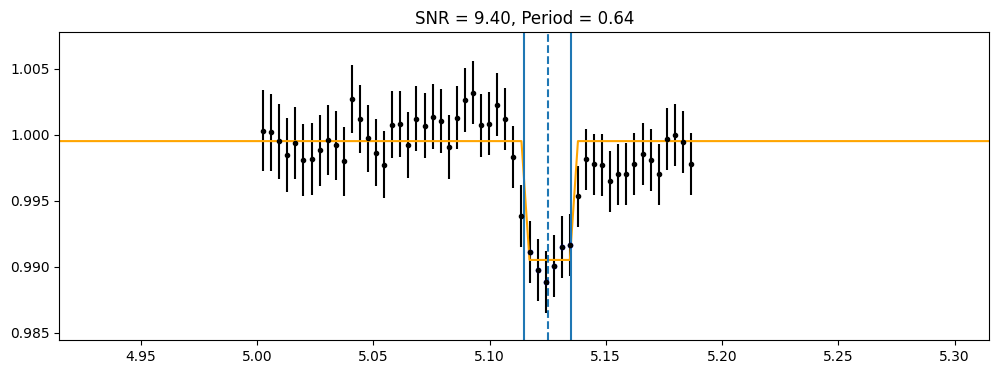

Time to BLS search: 0.8699252605438232
Transit was found - checking if it matches the injected transit!
Planet was successfully recovered
No transit found!

Time to inject-recover 1 planets: 7.439685106277466
Planets recovered: 100.0%
But did all of those planets transited during the observation window?...
Observed Planets recovered: 100.0%


In [6]:
x = full_injection_recovery(targ, 
                            lcs_with_transits=[targ_with_transit],
                                 planets=planets,
                                 nfake=1,
                                 minimum_planet_radius=0.25 * u.R_earth, 
                                 maximum_planet_radius=1 * u.R_earth,
                                 minimum_period=0.5 * u.d, 
                                 maximum_period=2 * u.d, 
                                 ld=[0.3,0.3],
                                 clean_kw = {'dust_removal': False, 'bad_weather_removal': False,'cosmics_removal': True,
                                             'threshold_removal':False, 'cosmic_boxsize':0.01, 'cosmic_nsigma':5, 'verbose':True},
                                 flare_kw = {'plot':True, 'min_flare_separation':60*u.minute, 'min_flare_duration':30*u.s,
                                             'tbuffer_after':30*u.min, 'n_consecutive_points':2, 'n_points':2, 
                                             'global_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': 5}, 
                                             'local_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},},
                                 detrend_method = "gp", 
                                 detrend_bin = 10 * u.minute,
                                 detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                               'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': True, 'verbose':True,
                                               'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                               'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), 
                                                                     np.log((np.max(targ.time)-np.min(targ.time)).value)]},
                                bls_kw = {"minimum_period":None, "maximum_period":None, 'minimum_n_transit':2, 'obj':'snr',
                                          'return_all_transits':False, 'transit_durations':[0.01,0.02,0.03,0.04], 'plot':True, 
                                          'verbose': True}, 
                                bls_bin=5 * u.minute,
                                recovery_kw = {'condition_on_epoch':1 * u.hour, 'min_n_transits': 1, 'meet_condition': 'any'},                           
                                verbose=True, plot=True, time_this_process=True)

In [ ]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x